# Predicting Student Health Risk

## Final Model Comparison

This notebook combines the evaluation results from the baseline models, tree-based models, and Artificial Neural Network. The models are compared using balanced accuracy, normal accuracy, Macro F1 score, and the difference between training and validation performance.

The main purpose is to select the strongest model for the final Kaggle submission and Flask application.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_folder = current_folder
else:
    project_folder = current_folder.parent

models_folder = project_folder / "models"
results_folder = project_folder / "outputs" / "results"
figures_folder = project_folder / "outputs" / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Project folder")
print(project_folder)

print()

print("Results folder")
print(results_folder)

Project folder
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project

Results folder
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\outputs\results


In [3]:
baseline_results_file = (
    results_folder
    / "baseline_model_comparison.csv"
)

tree_results_file = (
    results_folder
    / "tree_based_model_comparison.csv"
)

ann_results_file = (
    results_folder
    / "ann_tree_model_comparison.csv"
)

print("Baseline result file exists")
print(baseline_results_file.exists())

print()

print("Tree-based result file exists")
print(tree_results_file.exists())

print()

print("ANN result file exists")
print(ann_results_file.exists())

Baseline result file exists
True

Tree-based result file exists
True

ANN result file exists
True


In [4]:
if not baseline_results_file.exists():
    raise FileNotFoundError(
        "Run 04_baseline_models.ipynb before continuing"
    )

if not tree_results_file.exists():
    raise FileNotFoundError(
        "Run 05_tree_based_models.ipynb before continuing"
    )

print("Required model result files are available")

Required model result files are available


In [5]:
baseline_results = pd.read_csv(
    baseline_results_file
)

print("Baseline results loaded successfully")

baseline_results

Baseline results loaded successfully


,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Decision Tree,0.8977,0.8974,0.8289,0.6995
1,Logistic Regression,0.8566,0.8574,0.7980,0.6577
2,Dummy Classifier,0.3333,0.3333,0.8587,0.3080


In [6]:
baseline_results["Model"] = baseline_results[
    "Model"
].replace(
    {
        "Decision Tree": "Baseline Decision Tree"
    }
)

baseline_results

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Baseline Decision Tree,0.8977,0.8974,0.8289,0.6995
1,Logistic Regression,0.8566,0.8574,0.7980,0.6577
2,Dummy Classifier,0.3333,0.3333,0.8587,0.3080


In [7]:
baseline_model_types = {
    "Dummy Classifier": "Reference Model",
    "Logistic Regression": "Classical Model",
    "Baseline Decision Tree": "Classical Model"
}

baseline_results["Model Type"] = baseline_results[
    "Model"
].map(baseline_model_types)

baseline_results

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Model Type
0,Baseline Decision Tree,0.8977,0.8974,0.8289,0.6995,Classical Model
1,Logistic Regression,0.8566,0.8574,0.7980,0.6577,Classical Model
2,Dummy Classifier,0.3333,0.3333,0.8587,0.3080,Reference Model


In [8]:
tree_results = pd.read_csv(
    tree_results_file
)

print("Tree-based results loaded successfully")

tree_results

Tree-based results loaded successfully


,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,XGBoost,0.9113,0.9097,0.8730,0.7541
1,Random Forest,0.9175,0.9054,0.8927,0.7787
2,Decision Tree,0.9026,0.9020,0.8558,0.7308


In [9]:
tree_results["Model"] = tree_results[
    "Model"
].replace(
    {
        "Decision Tree": "Improved Decision Tree"
    }
)

tree_results

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,XGBoost,0.9113,0.9097,0.8730,0.7541
1,Random Forest,0.9175,0.9054,0.8927,0.7787
2,Improved Decision Tree,0.9026,0.9020,0.8558,0.7308


In [10]:
tree_model_types = {
    "Improved Decision Tree": "Classical Model",
    "Random Forest": "Ensemble Model",
    "XGBoost": "Ensemble Model"
}

tree_results["Model Type"] = tree_results[
    "Model"
].map(tree_model_types)

tree_results

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Model Type
0,XGBoost,0.9113,0.9097,0.8730,0.7541,Ensemble Model
1,Random Forest,0.9175,0.9054,0.8927,0.7787,Ensemble Model
2,Improved Decision Tree,0.9026,0.9020,0.8558,0.7308,Classical Model


In [11]:
all_model_results = pd.concat(
    [
        baseline_results,
        tree_results
    ],
    ignore_index=True
)

print("Baseline and tree-based results combined")

all_model_results

Baseline and tree-based results combined


,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Model Type
0,Baseline Decision Tree,0.8977,0.8974,0.8289,0.6995,Classical Model
1,Logistic Regression,0.8566,0.8574,0.7980,0.6577,Classical Model
2,Dummy Classifier,0.3333,0.3333,0.8587,0.3080,Reference Model
3,XGBoost,0.9113,0.9097,0.8730,0.7541,Ensemble Model
4,Random Forest,0.9175,0.9054,0.8927,0.7787,Ensemble Model
5,Improved Decision Tree,0.9026,0.9020,0.8558,0.7308,Classical Model


In [12]:
ann_available = False

if ann_results_file.exists():
    ann_saved_results = pd.read_csv(
        ann_results_file
    )

    ann_result = ann_saved_results[
        ann_saved_results["Model"]
        == "Artificial Neural Network"
    ].copy()

    if len(ann_result) > 0:
        ann_result["Model Type"] = "Deep Learning Model"

        all_model_results = pd.concat(
            [
                all_model_results,
                ann_result
            ],
            ignore_index=True
        )

        ann_available = True

        print("ANN result added successfully")
    else:
        print("ANN row was not found in the result file")
else:
    print("ANN result is not available yet")

ANN result added successfully


In [13]:
print("ANN included in the comparison")
print(ann_available)

ANN included in the comparison
True


In [14]:
required_columns = [
    "Model",
    "Model Type",
    "Training Balanced Accuracy",
    "Validation Balanced Accuracy",
    "Normal Accuracy",
    "Macro F1 Score"
]

missing_columns = []

for column in required_columns:
    if column not in all_model_results.columns:
        missing_columns.append(column)

print("Missing comparison columns")
print(missing_columns)

Missing comparison columns
[]


In [15]:
all_model_results = all_model_results[
    required_columns
].copy()

all_model_results

,Model,Model Type,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Baseline Decision Tree,Classical Model,0.8977,0.8974,0.8289,0.6995
1,Logistic Regression,Classical Model,0.8566,0.8574,0.7980,0.6577
2,Dummy Classifier,Reference Model,0.3333,0.3333,0.8587,0.3080
3,XGBoost,Ensemble Model,0.9113,0.9097,0.8730,0.7541
4,Random Forest,Ensemble Model,0.9175,0.9054,0.8927,0.7787
5,Improved Decision Tree,Classical Model,0.9026,0.9020,0.8558,0.7308
6,Artificial Neural Network,Deep Learning Model,0.9043,0.9027,0.8929,0.7783


In [16]:
all_model_results = all_model_results.drop_duplicates(
    subset=["Model"],
    keep="last"
)

print("Duplicated model names removed")

all_model_results

Duplicated model names removed


,Model,Model Type,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Baseline Decision Tree,Classical Model,0.8977,0.8974,0.8289,0.6995
1,Logistic Regression,Classical Model,0.8566,0.8574,0.7980,0.6577
2,Dummy Classifier,Reference Model,0.3333,0.3333,0.8587,0.3080
3,XGBoost,Ensemble Model,0.9113,0.9097,0.8730,0.7541
4,Random Forest,Ensemble Model,0.9175,0.9054,0.8927,0.7787
5,Improved Decision Tree,Classical Model,0.9026,0.9020,0.8558,0.7308
6,Artificial Neural Network,Deep Learning Model,0.9043,0.9027,0.8929,0.7783


In [17]:
all_model_results["Generalisation Gap"] = (
    all_model_results[
        "Training Balanced Accuracy"
    ]
    - all_model_results[
        "Validation Balanced Accuracy"
    ]
)

all_model_results[
    "Absolute Gap"
] = all_model_results[
    "Generalisation Gap"
].abs()

all_model_results

,Model,Model Type,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Generalisation Gap,Absolute Gap
0,Baseline Decision Tree,Classical Model,0.8977,0.8974,0.8289,0.6995,0.0003,0.0003
1,Logistic Regression,Classical Model,0.8566,0.8574,0.7980,0.6577,-0.0008,0.0008
2,Dummy Classifier,Reference Model,0.3333,0.3333,0.8587,0.3080,0.0000,0.0000
3,XGBoost,Ensemble Model,0.9113,0.9097,0.8730,0.7541,0.0016,0.0016
4,Random Forest,Ensemble Model,0.9175,0.9054,0.8927,0.7787,0.0121,0.0121
5,Improved Decision Tree,Classical Model,0.9026,0.9020,0.8558,0.7308,0.0006,0.0006
6,Artificial Neural Network,Deep Learning Model,0.9043,0.9027,0.8929,0.7783,0.0016,0.0016


In [18]:
def interpret_gap(gap):
    if gap < 0.03:
        return "Small gap"
    elif gap < 0.08:
        return "Moderate gap"
    else:
        return "Large gap"

In [19]:
all_model_results[
    "Gap Interpretation"
] = all_model_results[
    "Absolute Gap"
].apply(interpret_gap)

all_model_results

,Model,Model Type,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Generalisation Gap,Absolute Gap,Gap Interpretation
0,Baseline Decision Tree,Classical Model,0.8977,0.8974,0.8289,0.6995,0.0003,0.0003,Small gap
1,Logistic Regression,Classical Model,0.8566,0.8574,0.7980,0.6577,-0.0008,0.0008,Small gap
2,Dummy Classifier,Reference Model,0.3333,0.3333,0.8587,0.3080,0.0000,0.0000,Small gap
3,XGBoost,Ensemble Model,0.9113,0.9097,0.8730,0.7541,0.0016,0.0016,Small gap
4,Random Forest,Ensemble Model,0.9175,0.9054,0.8927,0.7787,0.0121,0.0121,Small gap
5,Improved Decision Tree,Classical Model,0.9026,0.9020,0.8558,0.7308,0.0006,0.0006,Small gap
6,Artificial Neural Network,Deep Learning Model,0.9043,0.9027,0.8929,0.7783,0.0016,0.0016,Small gap


In [20]:
final_model_comparison = all_model_results.sort_values(
    by=[
        "Validation Balanced Accuracy",
        "Macro F1 Score",
        "Absolute Gap"
    ],
    ascending=[
        False,
        False,
        True
    ]
).reset_index(drop=True)

final_model_comparison[
    "Rank"
] = range(
    1,
    len(final_model_comparison) + 1
)

final_model_comparison

,Model,Model Type,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Generalisation Gap,Absolute Gap,Gap Interpretation,Rank
0,XGBoost,Ensemble Model,0.9113,0.9097,0.8730,0.7541,0.0016,0.0016,Small gap,1
1,Random Forest,Ensemble Model,0.9175,0.9054,0.8927,0.7787,0.0121,0.0121,Small gap,2
2,Artificial Neural Network,Deep Learning Model,0.9043,0.9027,0.8929,0.7783,0.0016,0.0016,Small gap,3
3,Improved Decision Tree,Classical Model,0.9026,0.9020,0.8558,0.7308,0.0006,0.0006,Small gap,4
4,Baseline Decision Tree,Classical Model,0.8977,0.8974,0.8289,0.6995,0.0003,0.0003,Small gap,5
5,Logistic Regression,Classical Model,0.8566,0.8574,0.7980,0.6577,-0.0008,0.0008,Small gap,6
6,Dummy Classifier,Reference Model,0.3333,0.3333,0.8587,0.3080,0.0000,0.0000,Small gap,7


In [21]:
final_model_comparison = final_model_comparison[
    [
        "Rank",
        "Model",
        "Model Type",
        "Training Balanced Accuracy",
        "Validation Balanced Accuracy",
        "Normal Accuracy",
        "Macro F1 Score",
        "Generalisation Gap",
        "Gap Interpretation"
    ]
]

final_model_comparison = final_model_comparison.round(4)

final_model_comparison

,Rank,Model,Model Type,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score,Generalisation Gap,Gap Interpretation
0,1,XGBoost,Ensemble Model,0.9113,0.9097,0.8730,0.7541,0.0016,Small gap
1,2,Random Forest,Ensemble Model,0.9175,0.9054,0.8927,0.7787,0.0121,Small gap
2,3,Artificial Neural Network,Deep Learning Model,0.9043,0.9027,0.8929,0.7783,0.0016,Small gap
3,4,Improved Decision Tree,Classical Model,0.9026,0.9020,0.8558,0.7308,0.0006,Small gap
4,5,Baseline Decision Tree,Classical Model,0.8977,0.8974,0.8289,0.6995,0.0003,Small gap
5,6,Logistic Regression,Classical Model,0.8566,0.8574,0.7980,0.6577,-0.0008,Small gap
6,7,Dummy Classifier,Reference Model,0.3333,0.3333,0.8587,0.3080,0.0000,Small gap


In [22]:
best_model_row = final_model_comparison.iloc[0]

best_model_name = best_model_row["Model"]
best_model_type = best_model_row["Model Type"]

best_validation_score = best_model_row[
    "Validation Balanced Accuracy"
]

best_macro_f1 = best_model_row[
    "Macro F1 Score"
]

best_gap = best_model_row[
    "Generalisation Gap"
]

print("Selected best model")
print(best_model_name)

print()

print("Model type")
print(best_model_type)

print()

print("Validation balanced accuracy")
print(best_validation_score)

print()

print("Macro F1 score")
print(best_macro_f1)

print()

print("Generalisation gap")
print(best_gap)

Selected best model
XGBoost

Model type
Ensemble Model

Validation balanced accuracy
0.9097

Macro F1 score
0.7541

Generalisation gap
0.0016


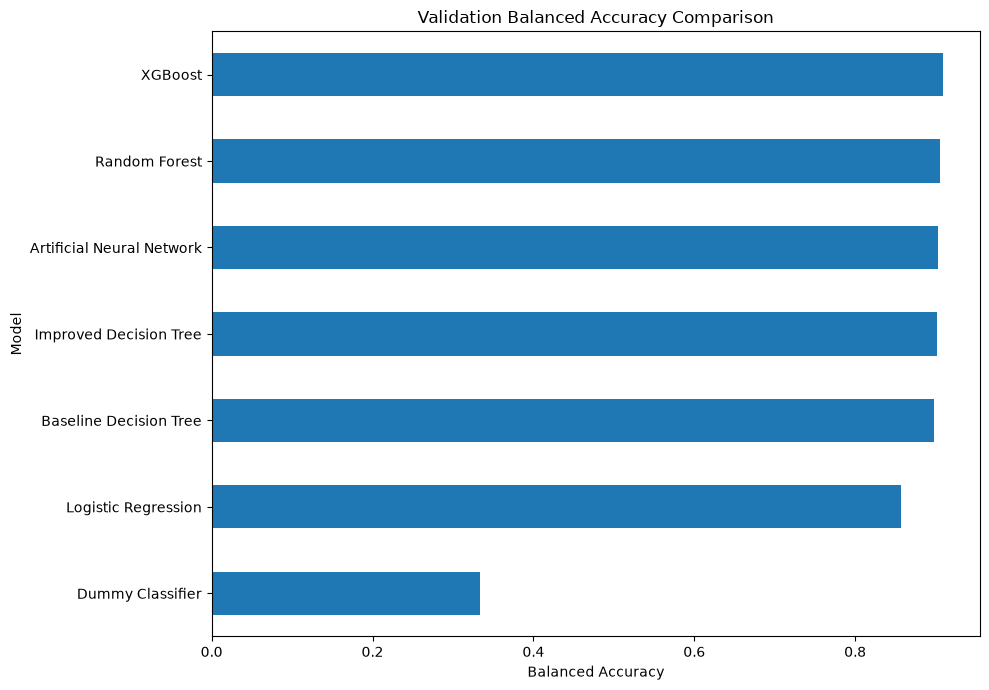

In [23]:
validation_chart_data = final_model_comparison.sort_values(
    by="Validation Balanced Accuracy",
    ascending=True
)

validation_chart_data.plot(
    x="Model",
    y="Validation Balanced Accuracy",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Validation Balanced Accuracy Comparison")
plt.xlabel("Balanced Accuracy")
plt.ylabel("Model")
plt.tight_layout()

validation_chart_file = (
    figures_folder
    / "final_validation_balanced_accuracy.png"
)

plt.savefig(validation_chart_file)
plt.show()

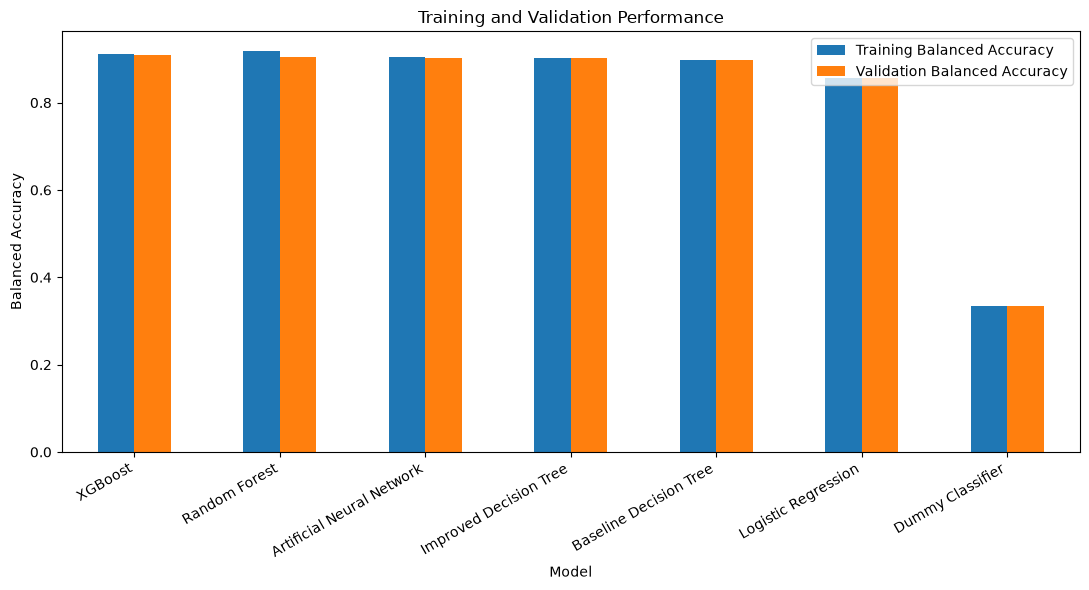

In [24]:
training_validation_data = final_model_comparison[
    [
        "Model",
        "Training Balanced Accuracy",
        "Validation Balanced Accuracy"
    ]
].copy()

training_validation_data = (
    training_validation_data
    .set_index("Model")
)

training_validation_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Training and Validation Performance")
plt.xlabel("Model")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

training_validation_chart_file = (
    figures_folder
    / "training_validation_comparison.png"
)

plt.savefig(training_validation_chart_file)
plt.show()

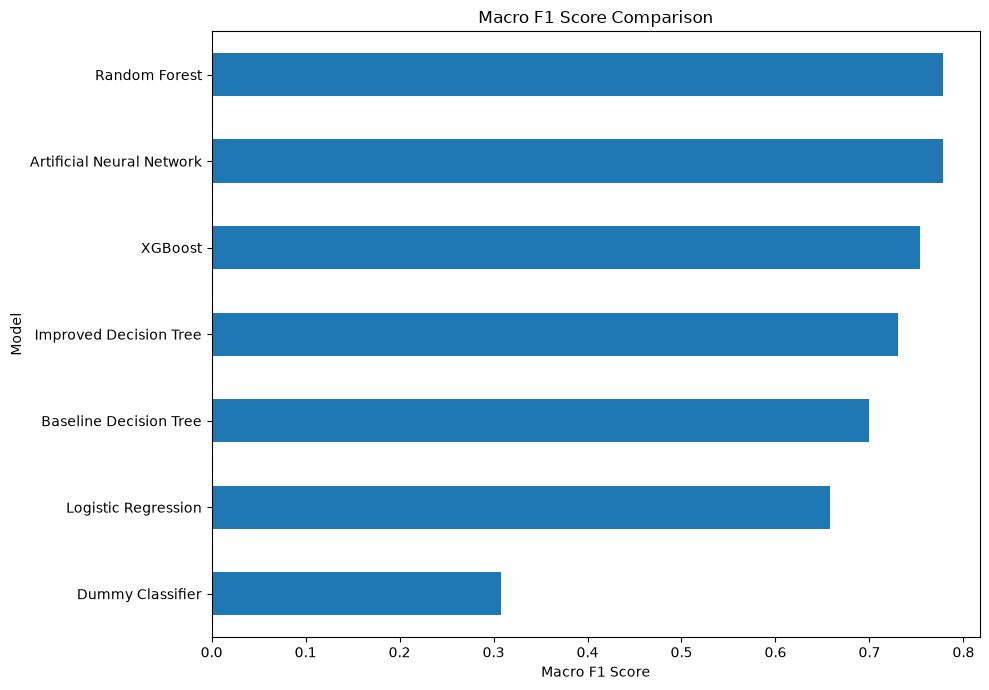

In [25]:
macro_f1_chart_data = final_model_comparison.sort_values(
    by="Macro F1 Score",
    ascending=True
)

macro_f1_chart_data.plot(
    x="Model",
    y="Macro F1 Score",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Macro F1 Score Comparison")
plt.xlabel("Macro F1 Score")
plt.ylabel("Model")
plt.tight_layout()

macro_f1_chart_file = (
    figures_folder
    / "final_macro_f1_comparison.png"
)

plt.savefig(macro_f1_chart_file)
plt.show()

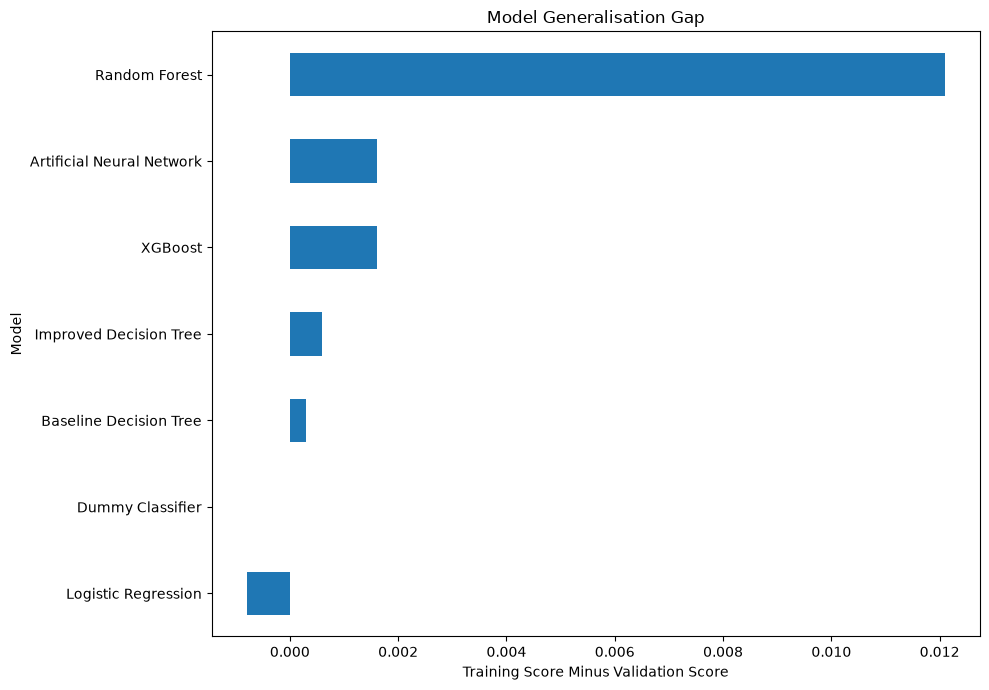

In [26]:
gap_chart_data = final_model_comparison.sort_values(
    by="Generalisation Gap",
    ascending=True
)

gap_chart_data.plot(
    x="Model",
    y="Generalisation Gap",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Model Generalisation Gap")
plt.xlabel("Training Score Minus Validation Score")
plt.ylabel("Model")
plt.tight_layout()

gap_chart_file = (
    figures_folder
    / "model_generalisation_gap.png"
)

plt.savefig(gap_chart_file)
plt.show()

In [27]:
model_file_mapping = {
    "Dummy Classifier": "dummy_classifier.joblib",
    "Logistic Regression": "logistic_regression.joblib",
    "Baseline Decision Tree": "decision_tree.joblib",
    "Improved Decision Tree": "decision_tree_improved.joblib",
    "Random Forest": "random_forest.joblib",
    "XGBoost": "xgboost_model.joblib",
    "Artificial Neural Network": "ann_model.keras"
}

selected_model_filename = model_file_mapping.get(
    best_model_name
)

print("Selected model filename")
print(selected_model_filename)

Selected model filename
xgboost_model.joblib


In [28]:
selected_model_path = (
    models_folder
    / selected_model_filename
)

print("Selected model path")
print(selected_model_path)

print()

print("Selected model file exists")
print(selected_model_path.exists())

Selected model path
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\models\xgboost_model.joblib

Selected model file exists
True


In [29]:
selected_model_information = {
    "selected_model": best_model_name,
    "model_type": best_model_type,
    "model_filename": selected_model_filename,
    "validation_balanced_accuracy": float(
        best_validation_score
    ),
    "macro_f1_score": float(
        best_macro_f1
    ),
    "generalisation_gap": float(
        best_gap
    ),
    "ann_included": ann_available
}

selected_model_information_file = (
    models_folder
    / "selected_model_information.joblib"
)

joblib.dump(
    selected_model_information,
    selected_model_information_file
)

print("Selected model information saved successfully")
print(selected_model_information_file)

Selected model information saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\models\selected_model_information.joblib


In [30]:
final_comparison_file = (
    results_folder
    / "final_model_comparison.csv"
)

final_model_comparison.to_csv(
    final_comparison_file,
    index=False
)

print("Final model comparison saved successfully")
print(final_comparison_file)

Final model comparison saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\outputs\results\final_model_comparison.csv


In [31]:
print("Final comparison file saved")
print(final_comparison_file.exists())

print()

print("Selected model information saved")
print(selected_model_information_file.exists())

print()

print("Validation chart saved")
print(validation_chart_file.exists())

print()

print("Training and validation chart saved")
print(training_validation_chart_file.exists())

print()

print("Macro F1 chart saved")
print(macro_f1_chart_file.exists())

print()

print("Generalisation gap chart saved")
print(gap_chart_file.exists())

Final comparison file saved
True

Selected model information saved
True

Validation chart saved
True

Training and validation chart saved
True

Macro F1 chart saved
True

Generalisation gap chart saved
True


## Final model comparison findings

A total of 7 models were compared.

XGBoost achieved the highest validation balanced accuracy of 0.9097.

Random Forest achieved the highest Macro F1 score of 0.7787.

The ANN achieved the highest normal accuracy of 0.8929, slightly above Random Forest.

XGBoost had a training balanced accuracy of 0.9113 and a generalisation gap of 0.0016.

XGBoost improved on the Dummy Classifier by 0.5764 balanced accuracy.

It also performed better than Logistic Regression, both Decision Trees, Random Forest, and the ANN on the main balanced accuracy measurement.

XGBoost was selected as the final model because it achieved the best score for the main evaluation metric while maintaining a small generalisation gap.

Deep learning was competitive, but it required more processing and did not outperform XGBoost.

A limitation is that the comparison mainly used one stratified training and validation split. Cross-validation and wider hyperparameter tuning could improve reliability.